# Text Halo: Default Color Across Themes and Flavors

When `halo_color` is omitted, the halo defaults to the **panel background** color, falling 
back to the **plot background** when the panel has no fill.


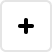
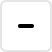
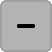
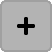
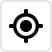
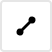
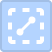
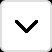
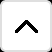
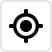
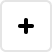
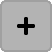
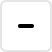
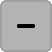
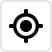
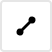
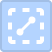
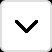
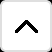
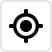

In [28]:
import pandas as pd
import numpy as np

from lets_plot import *

LetsPlot.setup_html()

In [29]:
mpg = (
    pd.read_csv('https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/mpg.csv')
    .drop(columns=['Unnamed: 0'])
)

# One label per manufacturer (the highest-hwy row), so labels land on top of the point cloud.
sample = (
    mpg.sort_values('hwy', ascending=False)
    .groupby('manufacturer', as_index=False)
    .head(1)
)
sample.head(3)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
221,volkswagen,new beetle,1.9,1999,4,manual(m5),f,35,44,d,subcompact
196,toyota,corolla,1.8,2008,4,manual(m5),f,28,37,r,compact
105,honda,civic,1.8,2008,4,auto(l5),f,25,36,r,subcompact


In [30]:
HALO_WIDTH = 1.6

def labeled(title, *extras, halo_width=HALO_WIDTH, halo_color=None):
    """Scatter + bold text labels with a halo. `halo_color=None` exercises the default."""
    p = (
        ggplot(mpg, aes('displ', 'hwy'))
        + geom_point(aes(color='drv'), size=4, alpha=.7, show_legend=False)
        + geom_text(
            aes(label='manufacturer'), data=sample,
            size=7, fontface='bold',
            check_overlap=False,        # intentionally for this example to test overlapping
            halo_width=halo_width, 
            halo_color=halo_color,
        )
        + ggtitle(title)
        + ggsize(440, 320)
    )
    for e in extras:
        p += e
    return p

## Without halo

With default settings the labels are unreadable, especailly the overlapped ones.

In [31]:
labeled('Without halo', halo_width=0)

## Default halo_color across all themes

Adding halo can help even with the default color. Here `halo_color` is omitted in every panel, so each halo is the theme's panel background.

In [32]:
themes = {
    'theme_grey':     theme_grey(),
    'theme_light':    theme_light(),
    'theme_classic':  theme_classic(),
    'theme_minimal':  theme_minimal(),
    'theme_minimal2': theme_minimal2(),
    'theme_bw':       theme_bw(),
    'theme_void':     theme_void(),
    'theme_none':     theme_none(),
}

gggrid([labeled(name, t) for name, t in themes.items()], ncol=2)

## Default halo across all flavors

Flavors are applied on top of `theme_grey()` so the panel has a flavor-specific fill.
Dark flavors should yield dark halos automatically.

In [33]:
flavors = {
    'flavor_standard':            flavor_standard(),
    'flavor_darcula':             flavor_darcula(),
    'flavor_solarized_light':     flavor_solarized_light(),
    'flavor_solarized_dark':      flavor_solarized_dark(),
    'flavor_high_contrast_light': flavor_high_contrast_light(),
    'flavor_high_contrast_dark':  flavor_high_contrast_dark(),
}

gggrid([labeled(name, theme_grey(), f) for name, f in flavors.items()], ncol=2)